## Identify early increasing genes

In [1]:
import xarray as xr
data = xr.load_dataset("data/white_dataset_mean.nc").sel(time=slice(0, 120))
data

<xarray.Dataset> Size: 5MB
Dimensions:          (time: 18, ensembl_gene_id: 30260)
Coordinates:
  * time             (time) float64 144B 0.0 0.75 2.25 3.0 ... 72.0 96.0 120.0
  * ensembl_gene_id  (ensembl_gene_id) object 242kB 'ENSDARG00000000001' ... ...
Data variables:
    y                (time, ensembl_gene_id) float64 4MB 2.782 0.3486 ... 0.0

In [15]:
import xarray as xr
import pandas as pd
import numpy as np

data = xr.load_dataset("data/white_dataset_mean.nc")
#data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean_wSource.nc").sel(source="White et al.")
nonzero_mask = (data.y != 0).any(dim='time') & (data.y.max(dim="time") > 1)
data = data.sel(ensembl_gene_id = data.ensembl_gene_id[nonzero_mask]).sel(time=slice(0, 6))

y0 = data.y.sel(time = 0)
y1 = data.y.sel(time = 0.75)
y2 = data.y.sel(time = 2.25)
y3 = data.y.sel(time = 6.0)
ymin = data.y.min(dim="time")

mask1 = y1 > y0
mask2 = y2 > y0
mask = (y2 > y0) & (y1 > y0) & (y2 > y1) #& (y3 < y0)
ds_increasing = data.sel(ensembl_gene_id = data.ensembl_gene_id[mask].values)

tails = pd.read_csv("data/Subtelny/tail_lengths.csv")

''' Winata '''
## miR-430 and Ythdf2 target genes 
winata_mir = pd.read_excel("data/Winata/TableS11_winata_miR-430_Ythdf2_targets.xlsx")
print(len(winata_mir.elements))

## maternal CPA genes
winata_mat = pd.read_excel("data/Winata/TableS2_winata_expression_cluster.xlsx", sheet_name="oligodT.maternal")
winata_preMBT = pd.read_excel("data/Winata/TableS2_winata_expression_cluster.xlsx", sheet_name="oligodT.preMBT")
winata_mat_CPA = pd.read_excel("data/Winata/TableS2_winata_expression_cluster.xlsx", sheet_name="ribozero.maternal CPA", header=1)
winata_mat_nonCPA = pd.read_excel("data/Winata/TableS2_winata_expression_cluster.xlsx", sheet_name="ribozero.maternal non-CPA")
print(len(winata_mat_CPA))
#winata = pd.concat([winata_mat, winata_preMBT])
#winata_mat_mir = winata[winata["gene name"].isin(winata_mir.elements.values)]

## CPA genes and miR targets
winata_mat_mir = winata_mat_CPA[winata_mat_CPA["gene name"].isin(winata_mir.elements.values)]
## Increasing genes
inc_winata_genes = winata_mat_mir[winata_mat_mir["#geneid"].isin(ds_increasing.ensembl_gene_id.values)]
inc_winata_genes = inc_winata_genes.rename(columns={"#geneid": "GeneID", "gene name": "GeneName"})
inc_winata_genes = inc_winata_genes[inc_winata_genes["GeneID"].isin(tails.GeneID.values)]
inc_winata_genes.to_csv("data/inc_winata_genes.csv", index=False)
inc_winata_genes

670


c:\Users\mgrho\anaconda3\envs\thesis2\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
c:\Users\mgrho\anaconda3\envs\thesis2\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


3667


,GeneID,GeneName,Egg,1Cell,16Cells,128c,3.5hpf,5.3hpf,#geneid.1,gene name.1,Egg.1,1Cell.1,16Cells.1,128c.1,3.5hpf.1,5.3hpf.1
2,ENSDARG00000043213,adam17a,37.403300,42.34490,42.341800,34.69750,40.935700,34.597000,ENSDARG00000043213,adam17a,4.28157,5.688180,26.59320,26.860300,35.86870,22.44870
34,ENSDARG00000070801,opa1,47.811220,72.11451,77.301300,64.30340,54.580170,6.190046,ENSDARG00000070801,opa1,13.10108,17.917250,44.53510,53.098740,45.59760,4.42245
39,ENSDARG00000010862,amt,28.055650,28.71716,28.442320,34.17488,14.371660,2.087834,ENSDARG00000010862,amt,11.23579,12.698490,56.70120,61.008800,25.09664,2.99565
46,ENSDARG00000074915,etaa1,115.864000,146.76300,132.081000,146.92600,41.245400,11.110300,ENSDARG00000074915,etaa1,6.46629,9.251720,29.90620,40.481200,38.45200,12.06100
57,ENSDARG00000023152,wdr73,86.437000,70.45720,84.296700,79.93840,40.840500,6.036800,ENSDARG00000023152,wdr73,6.39096,16.310800,30.55790,44.318500,40.18690,5.94853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3562,ENSDARG00000032516,rrp36,150.475000,126.94300,159.619000,131.97400,94.962900,73.079200,ENSDARG00000032516,rrp36,4.31245,6.516770,21.59440,22.089900,35.48940,21.26850
3567,ENSDARG00000071868,znf711,78.324300,65.33440,40.795500,48.25030,40.425800,14.969000,ENSDARG00000071868,znf711,3.47824,2.290850,28.74470,37.416000,40.29070,7.73082
3579,ENSDARG00000094992,otx1b,136.223000,132.58800,137.667000,140.17000,62.050700,12.603900,ENSDARG00000094992,otx1b,39.77370,45.920800,139.15200,154.175000,171.01200,18.18270
3605,ENSDARG00000070604,zgc:162509,38.692500,48.62440,25.038520,19.00760,35.124970,7.017493,ENSDARG00000070604,zgc:162509,5.13533,6.326200,25.05560,29.503309,25.29740,3.42389


In [ ]:
# NON CPA genes
winata_mat_nonCPA = winata_mat_nonCPA.rename(columns={"#geneid": "GeneID", "gene name": "GeneName"})
winata_mat_nonCPA_mir = winata_mat_nonCPA[winata_mat_nonCPA["GeneName"].isin(winata_mir.elements.values)]
winata_mat_nonCPA_mir = winata_mat_nonCPA_mir[winata_mat_nonCPA_mir["GeneID"].isin(data.ensembl_gene_id.values)]
winata_mat_nonCPA_mir = winata_mat_nonCPA_mir[~winata_mat_nonCPA_mir["GeneID"].isin(ds_increasing.ensembl_gene_id.values)]
#winata_mat_nonCPA_mir.to_csv("winata_nonCPA_genes.csv", index=False)

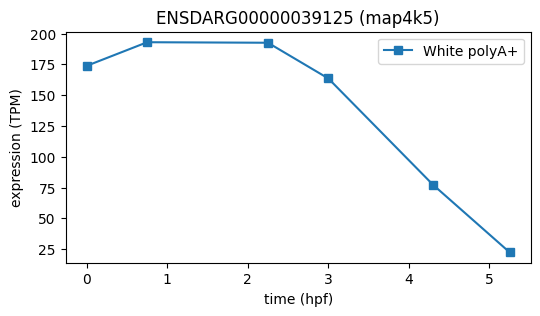

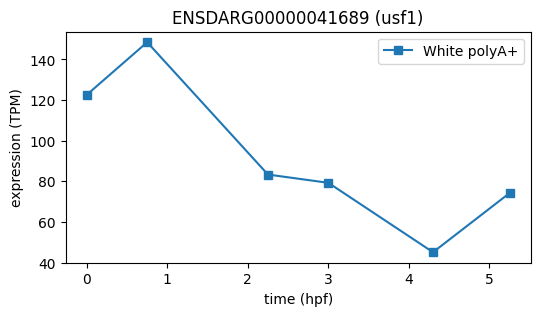

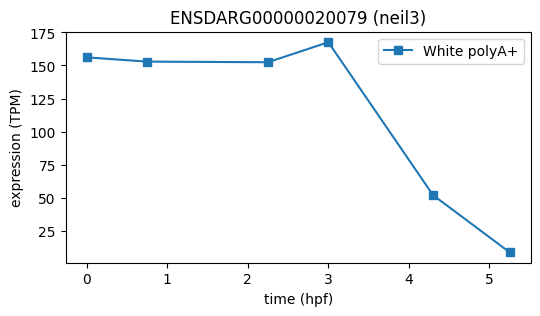

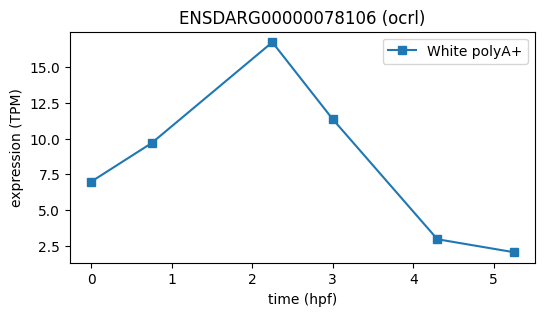

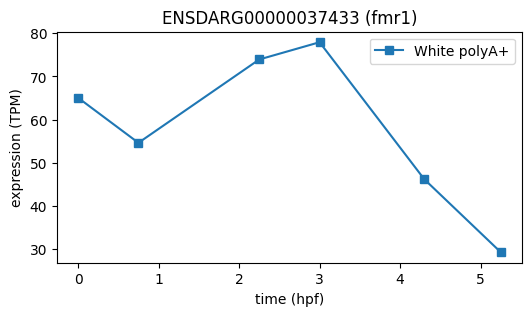

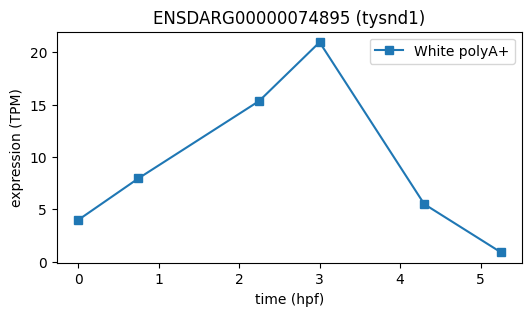

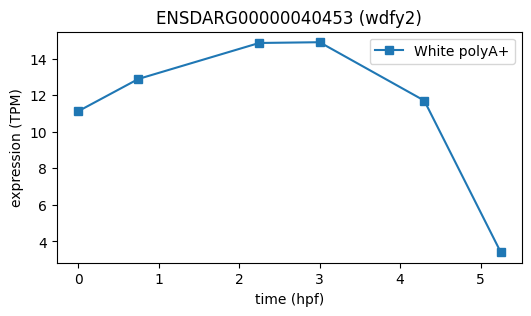

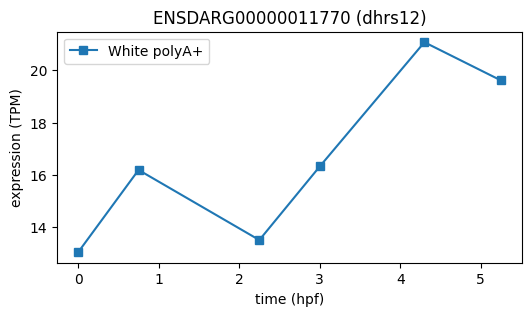

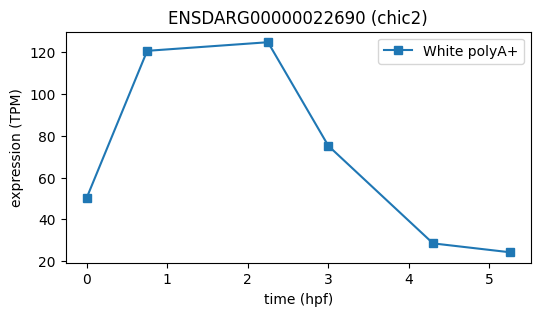

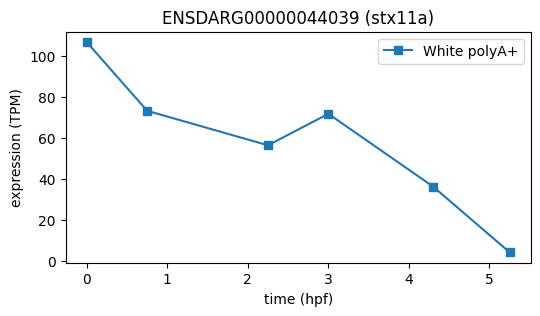

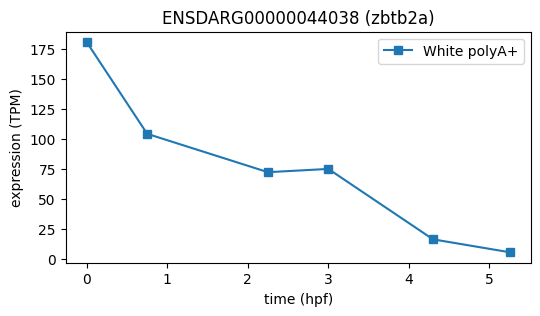

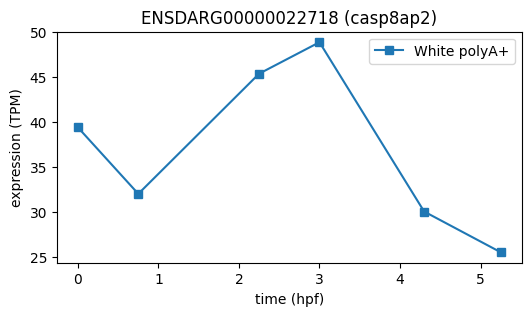

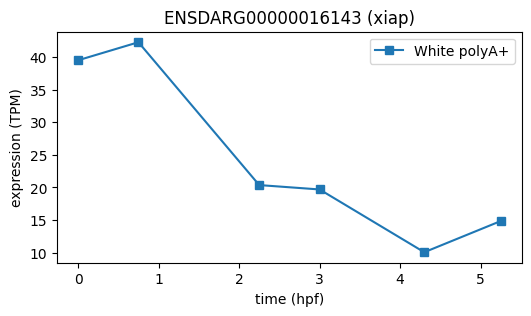

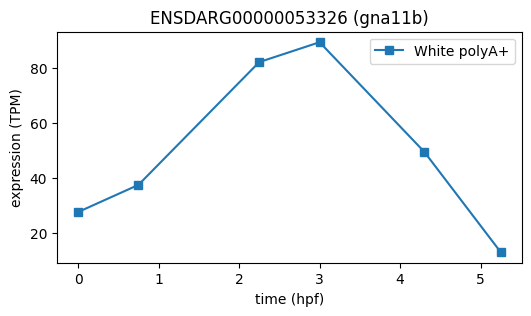

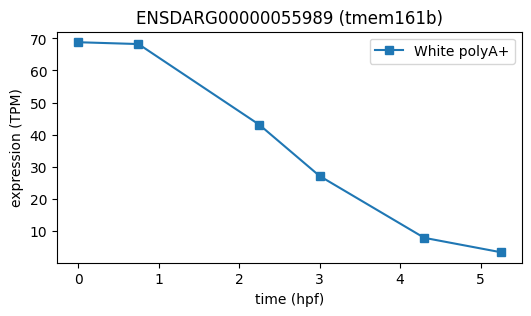

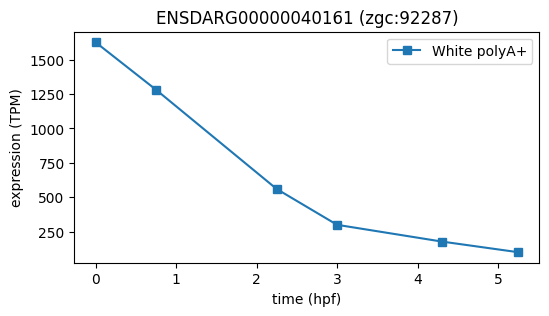

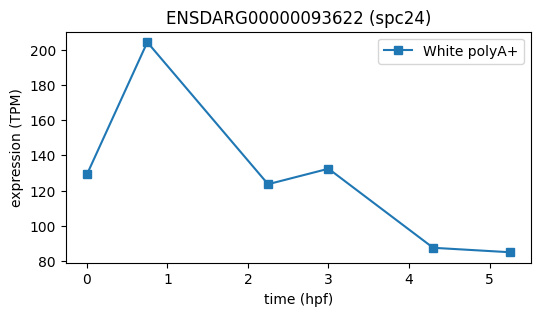

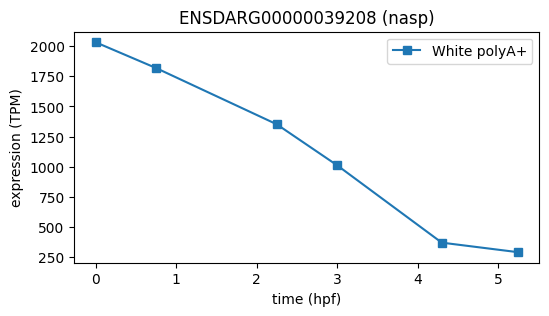

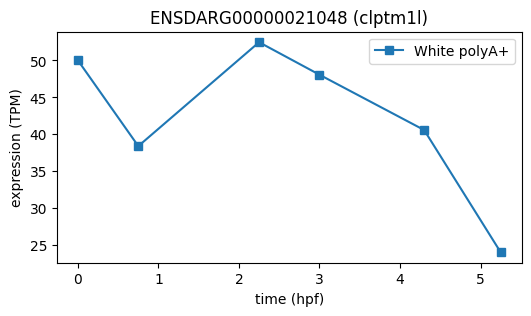

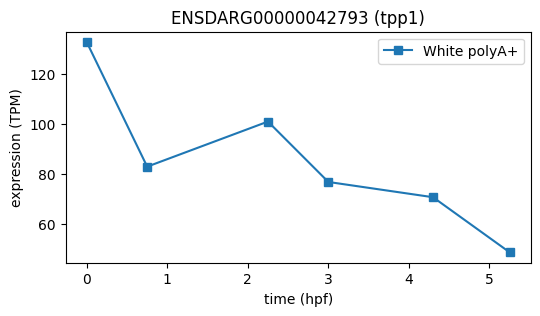

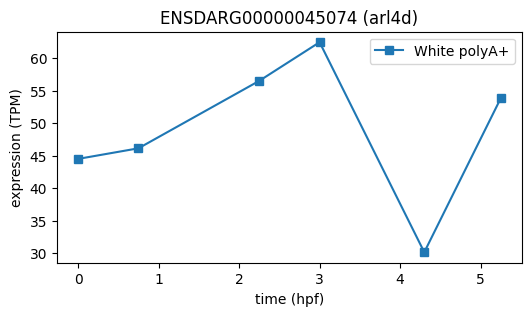

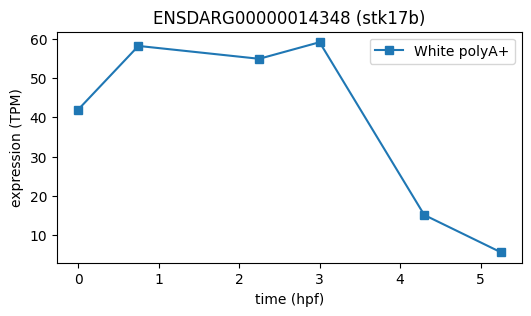

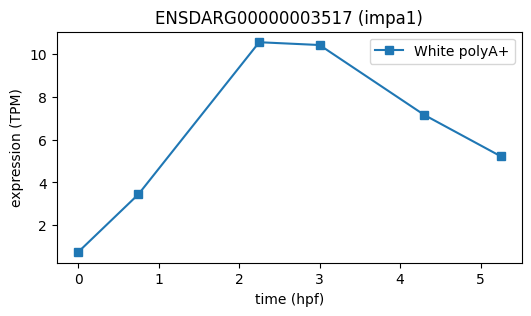

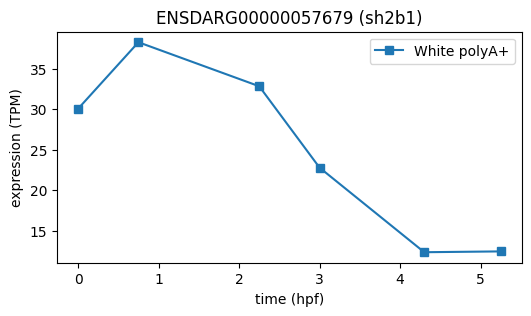

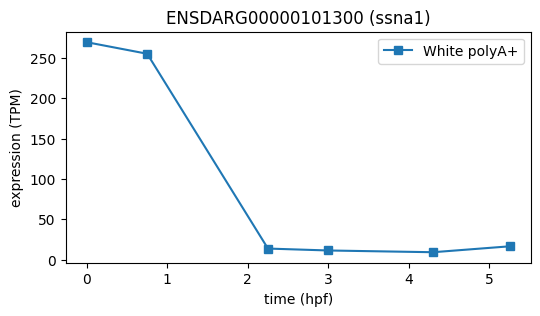

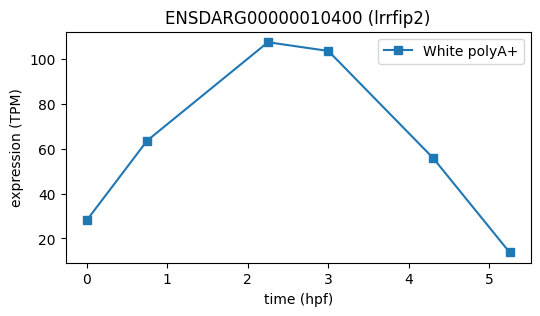

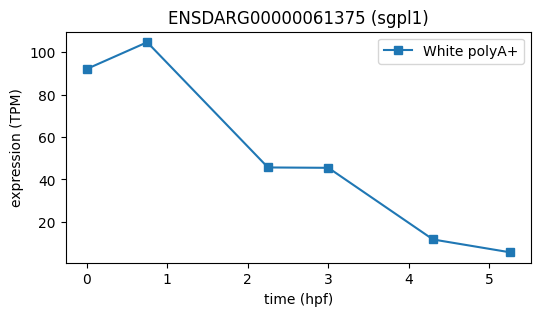

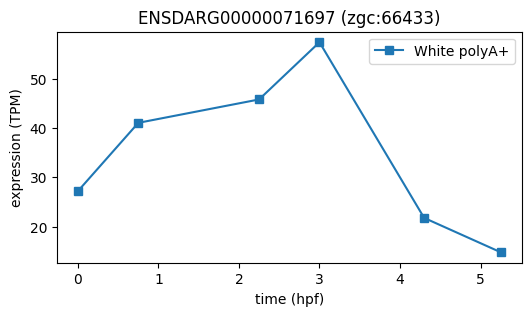

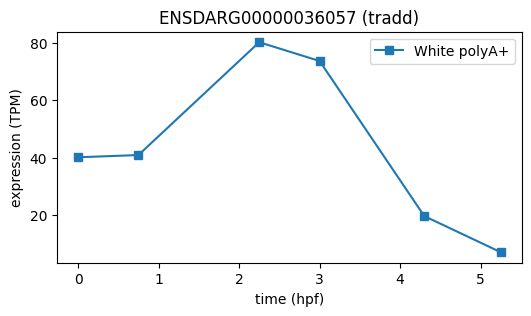

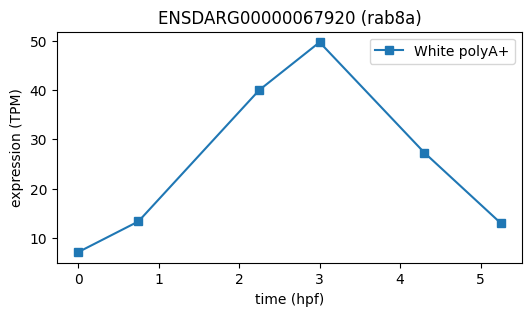

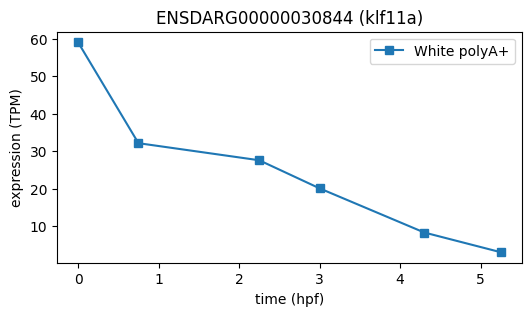

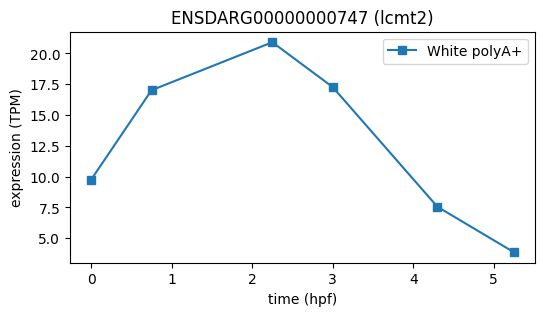

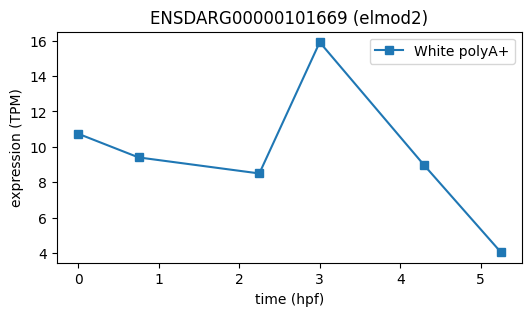

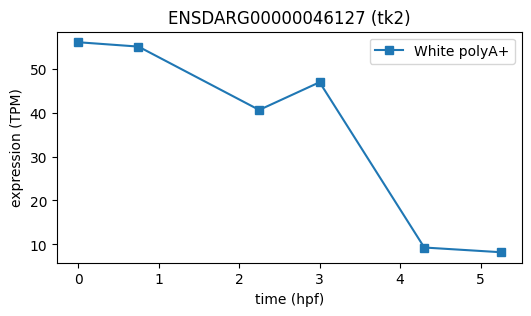

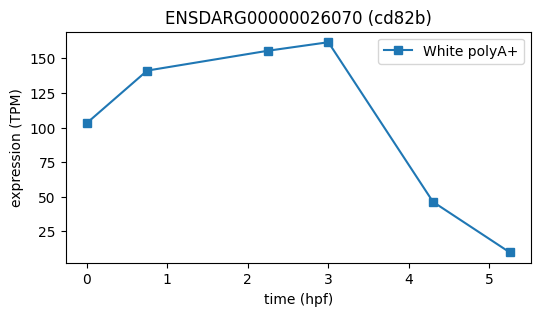

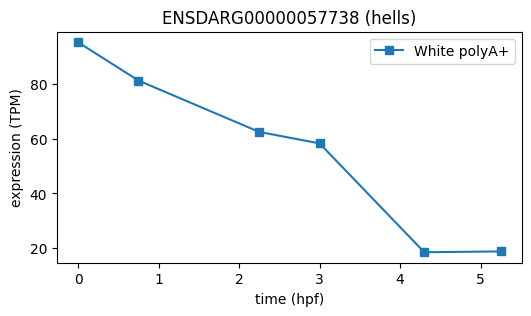

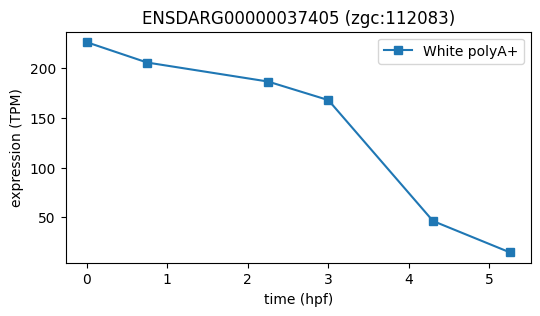

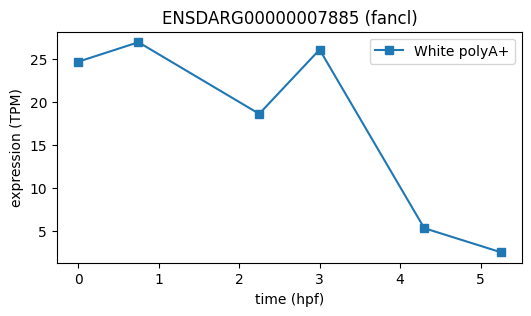

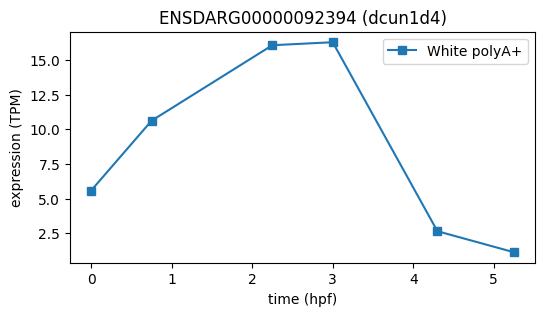

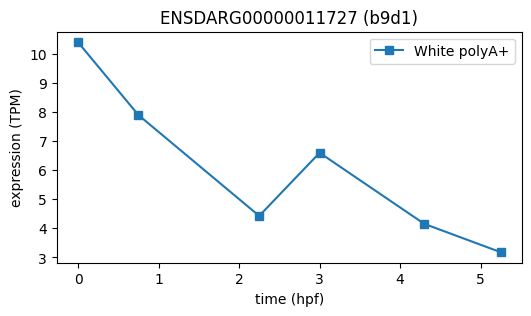

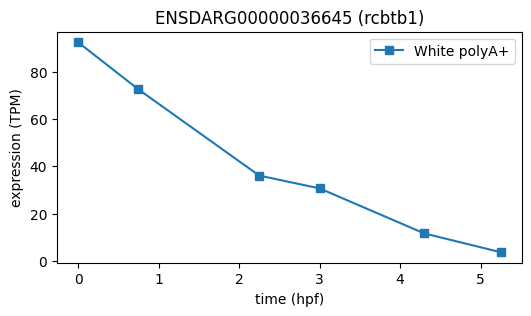

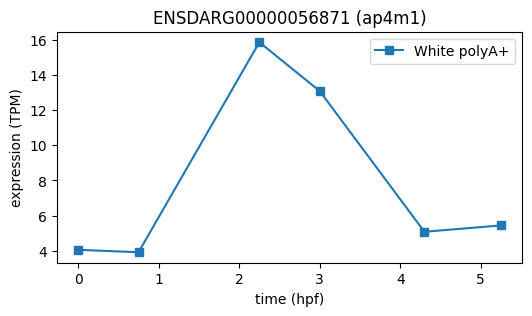

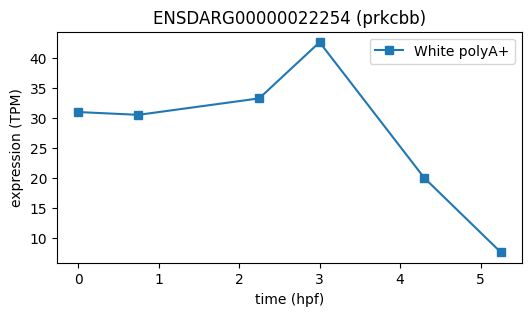

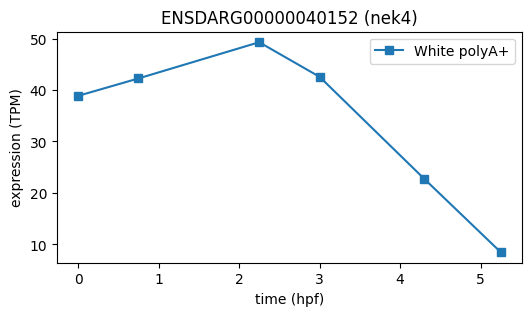

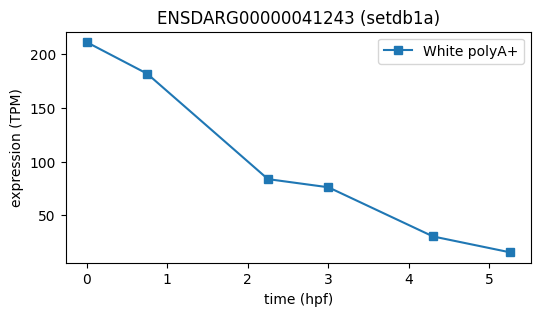

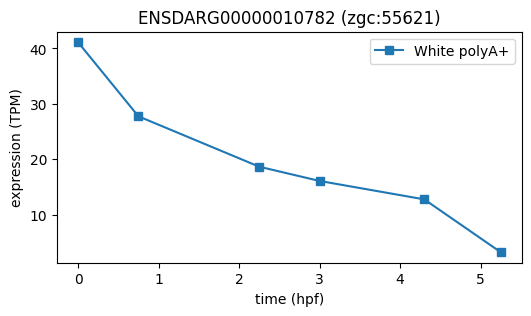

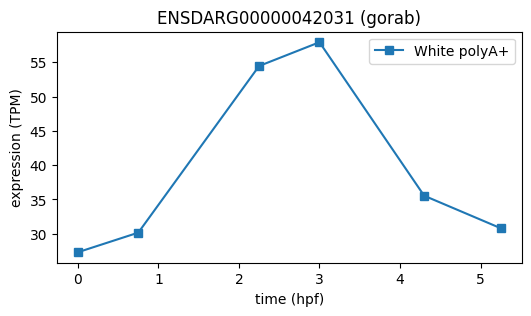

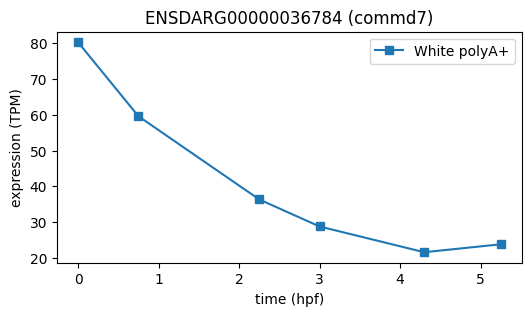

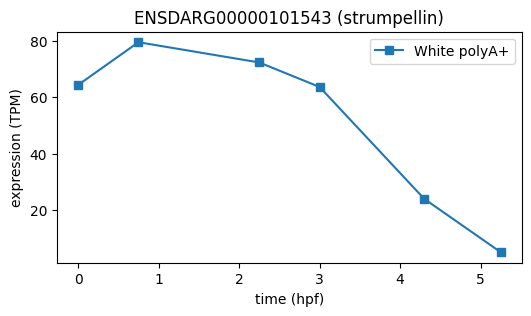

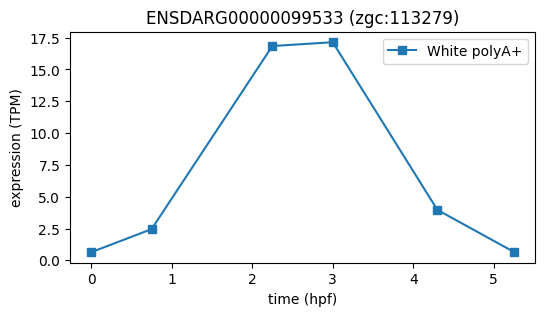

In [48]:
import matplotlib.pyplot as plt
data_white = xr.load_dataset("data/white_dataset_mean.nc").sel(time=slice(0, 5.25))

for gid in winata_mat_nonCPA_mir.GeneID.values[0:50]:
    gene = winata_mat_nonCPA_mir.loc[winata_mat_nonCPA_mir["GeneID"] == gid]
    gname = gene.GeneName.item()
    gene_white = data_white.sel(ensembl_gene_id = gid).y


    fig, ax = plt.subplots(figsize=(6,3))
    ax.plot(data_white.time, gene_white, "s-", label="White polyA+",  c="tab:blue")
    ax.set(title=f"{gid} ({gname})", xlabel="time (hpf)", ylabel="expression (TPM)")
    ax.legend()
    plt.show()

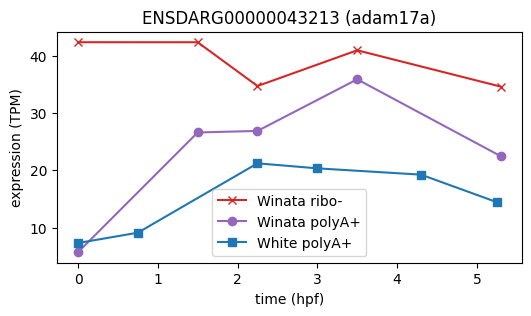

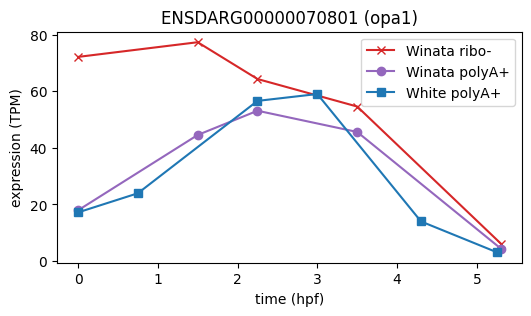

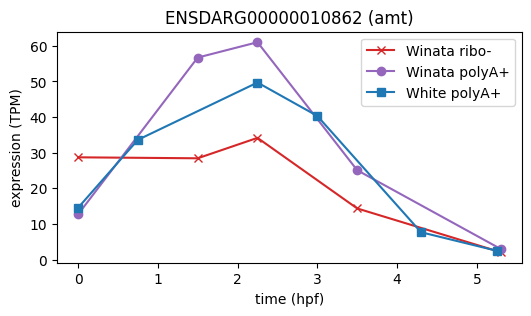

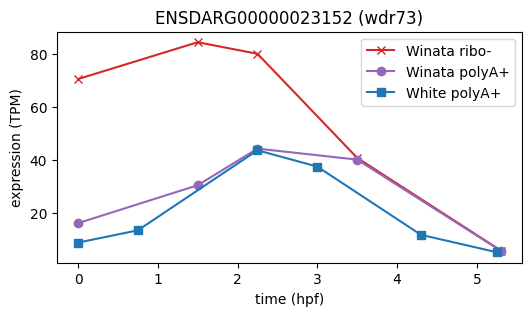

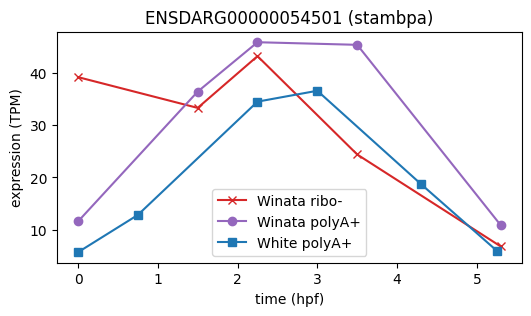

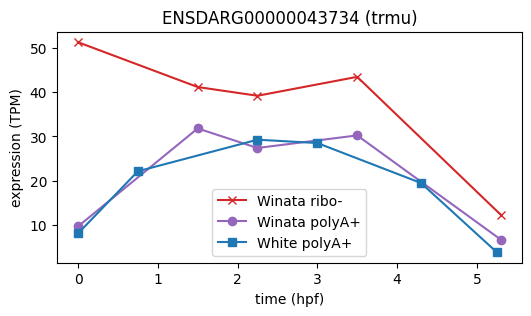

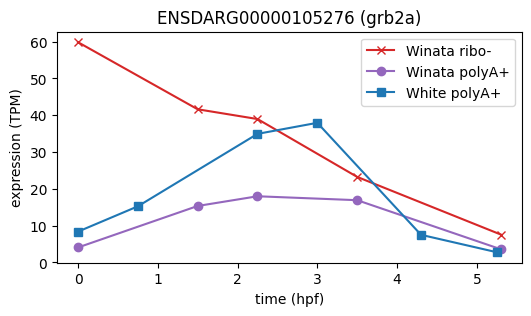

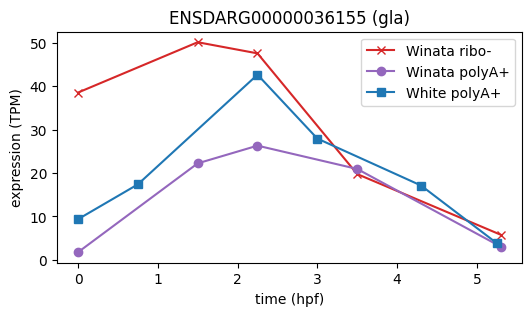

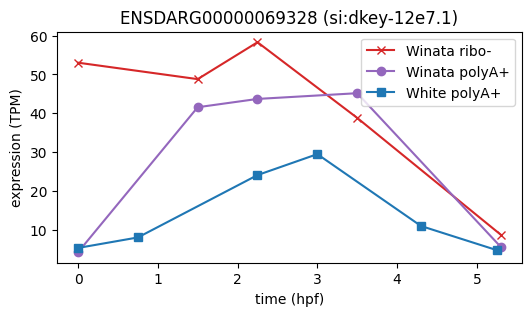

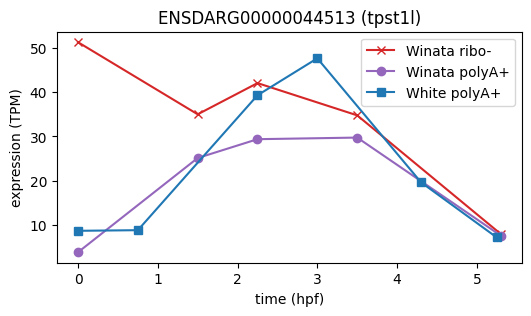

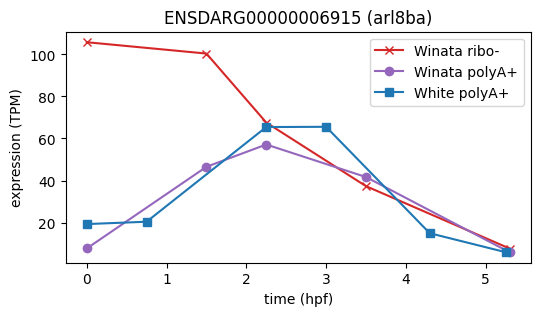

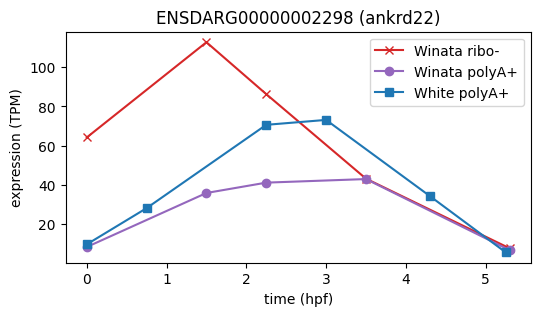

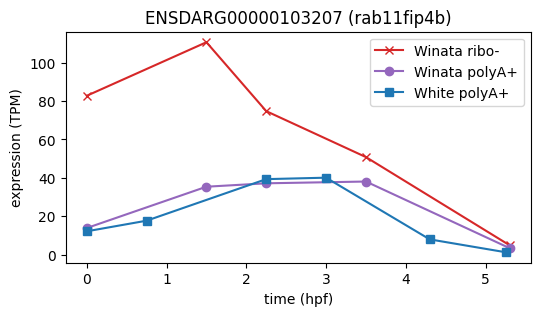

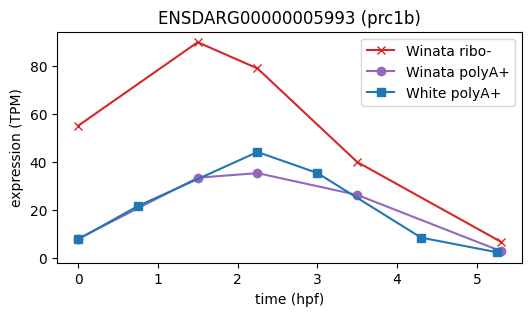

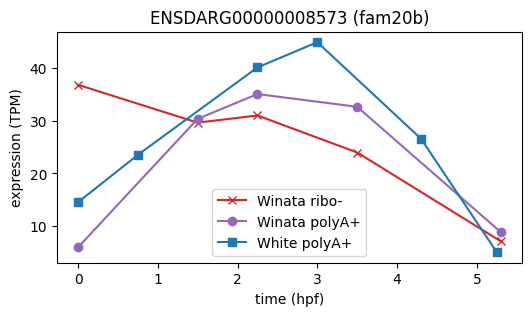

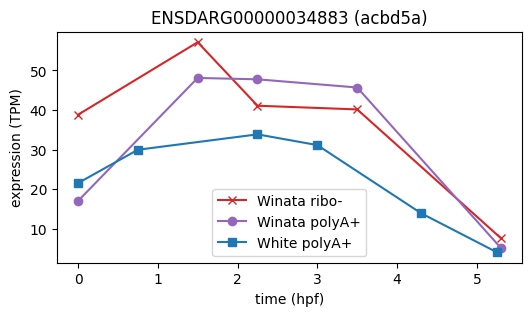

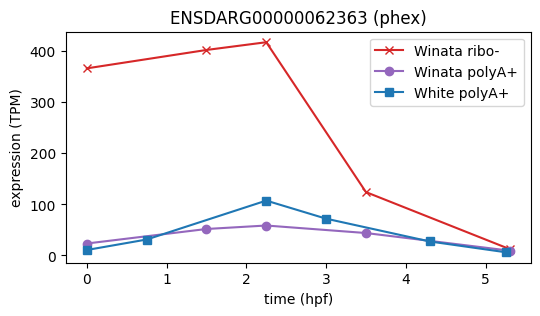

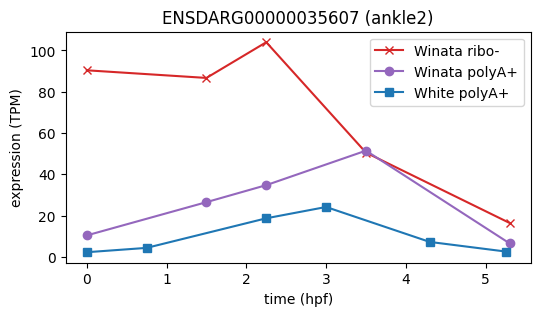

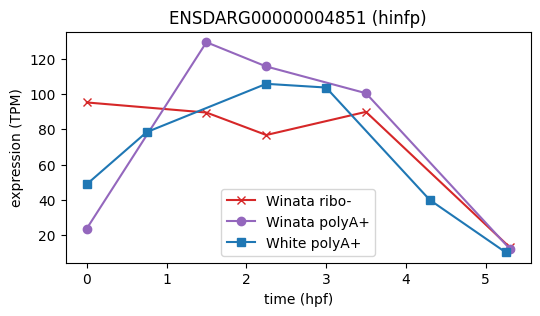

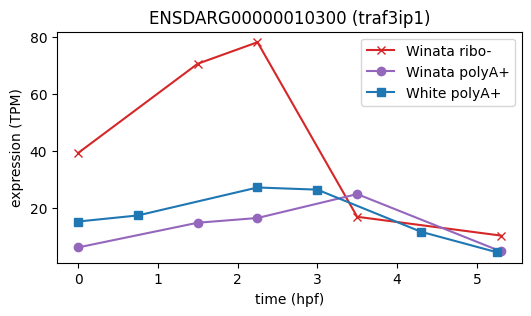

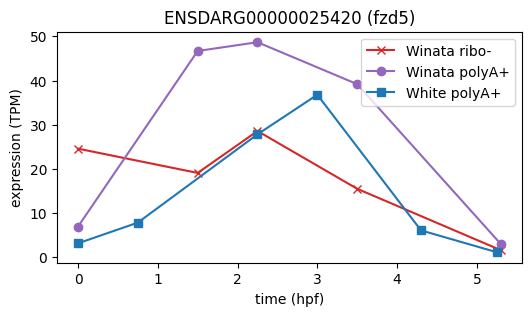

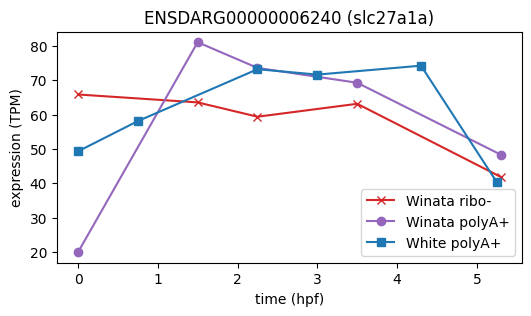

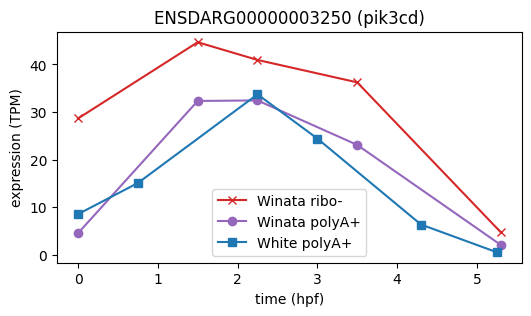

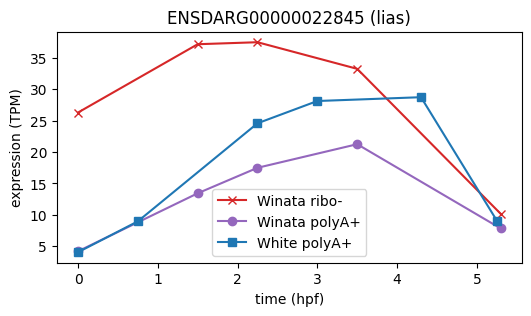

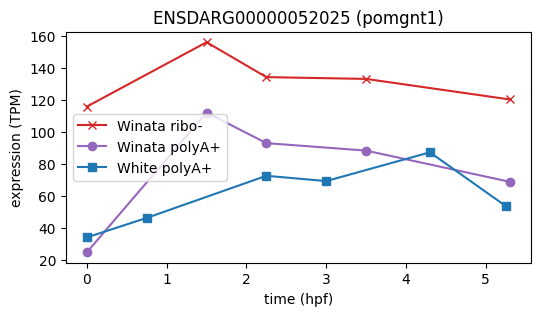

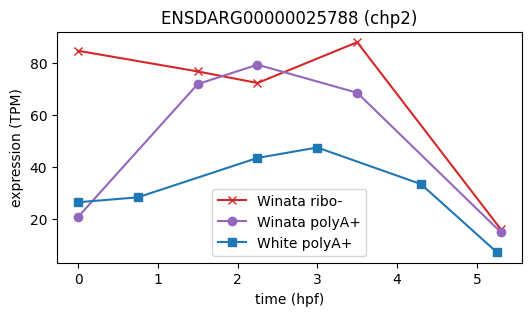

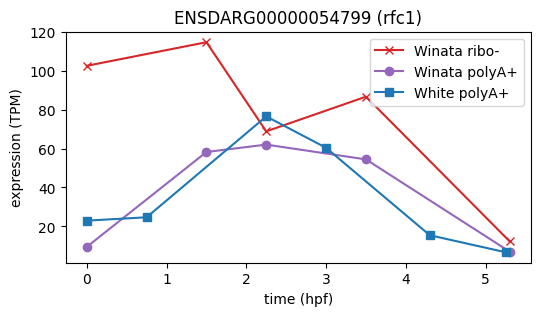

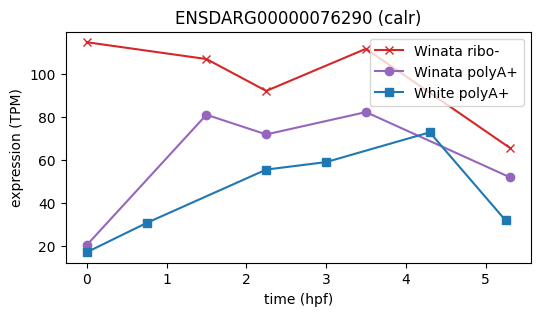

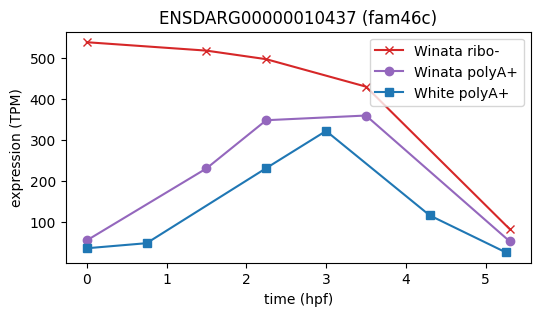

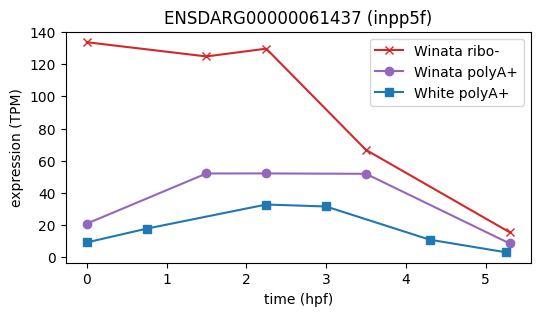

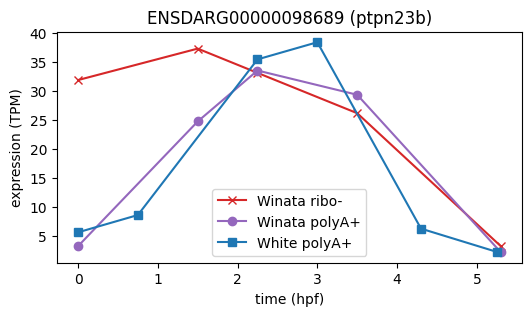

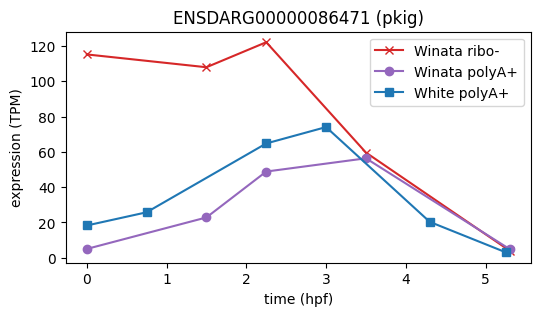

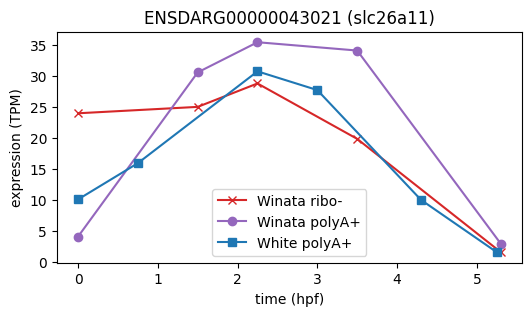

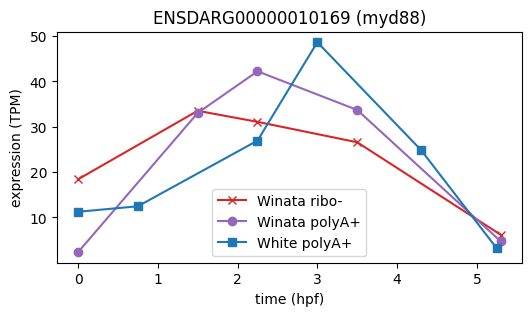

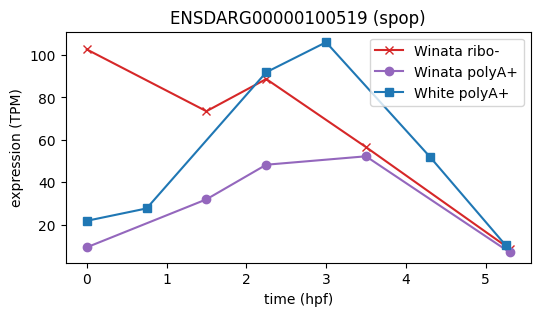

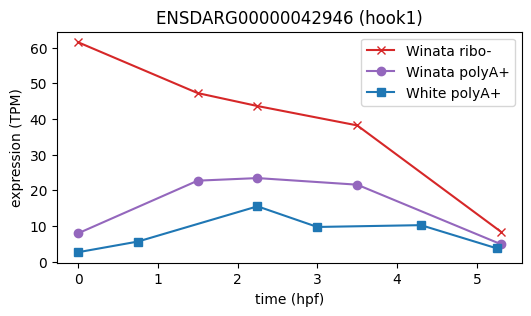

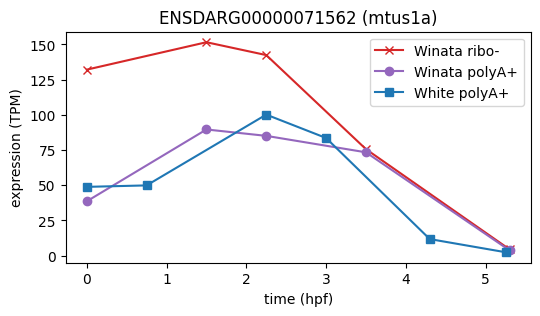

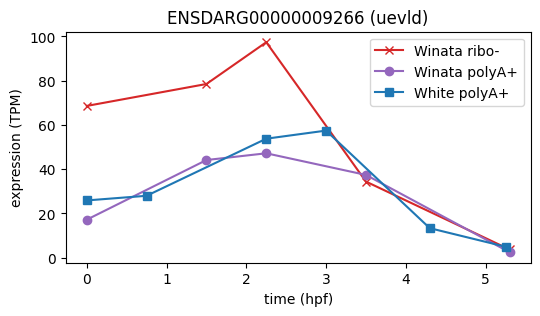

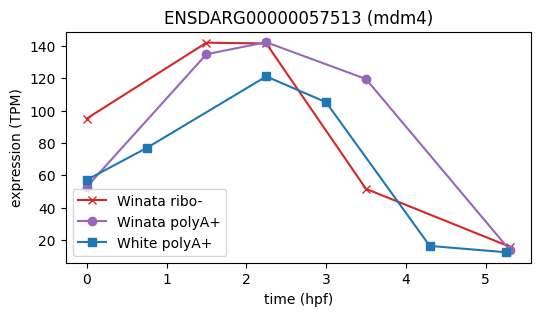

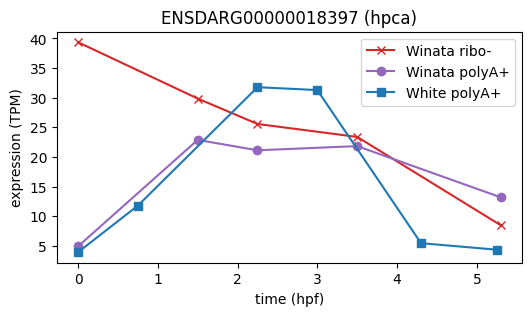

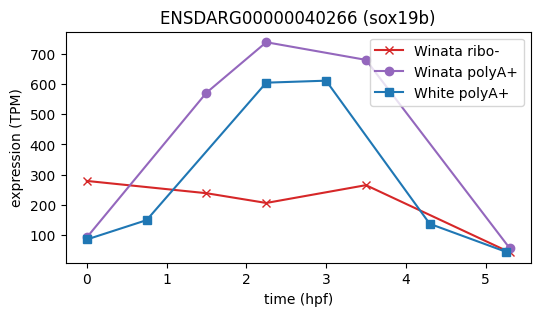

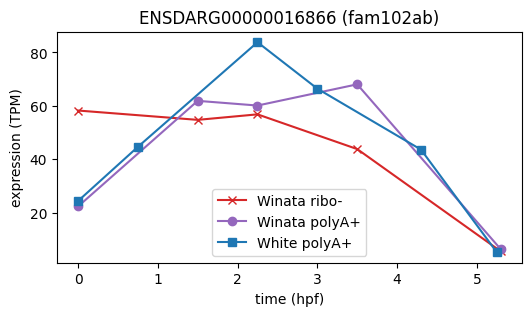

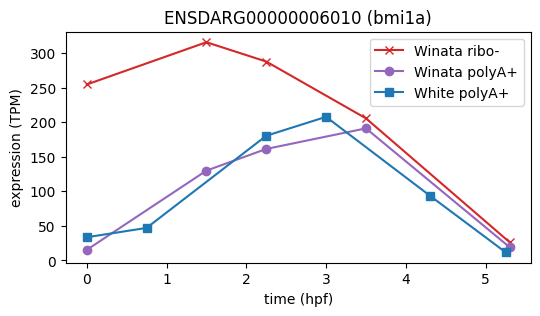

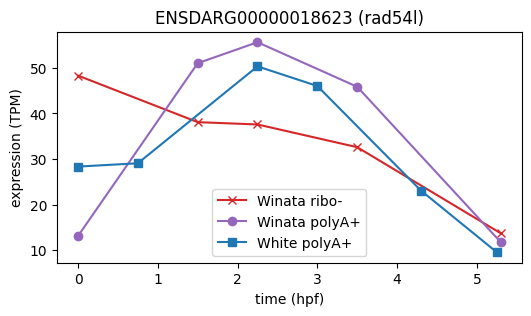

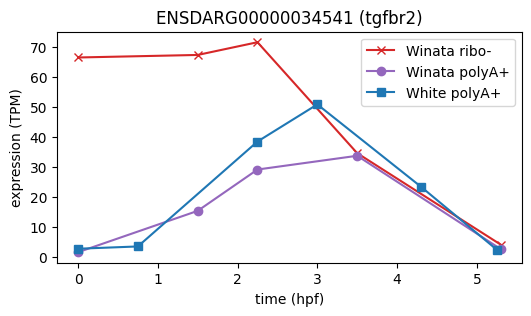

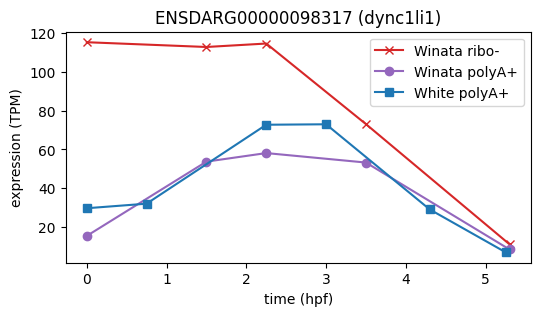

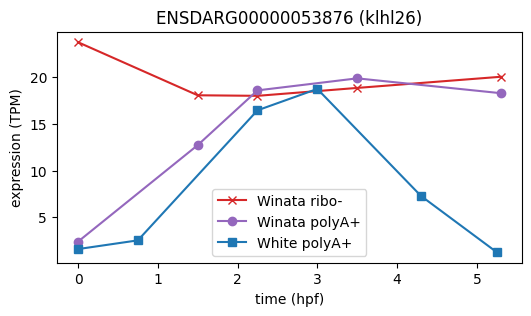

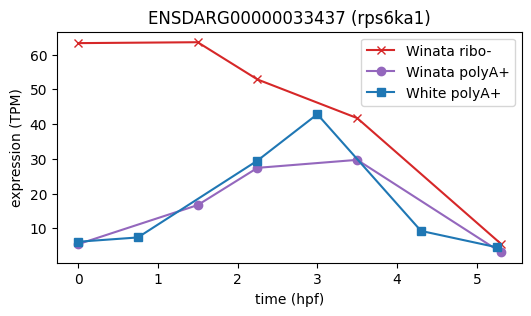

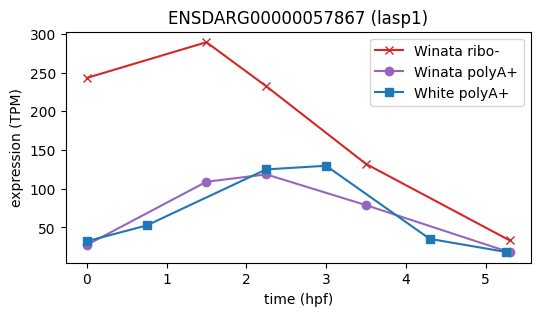

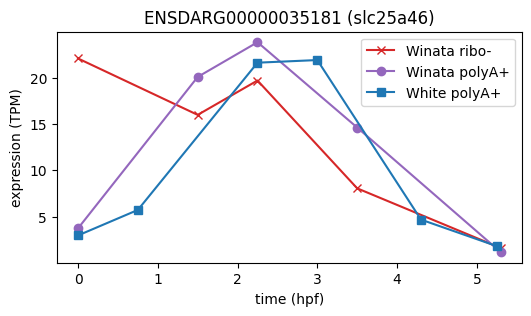

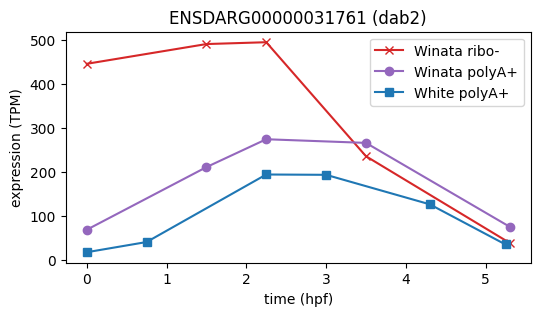

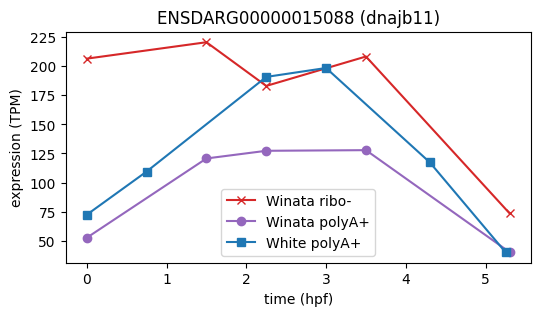

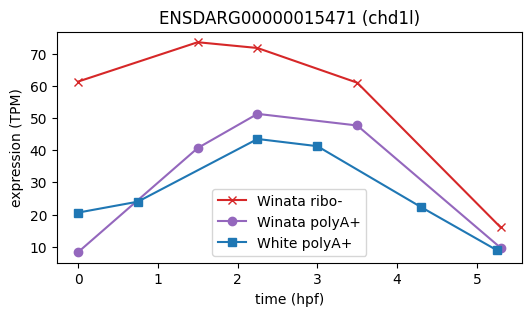

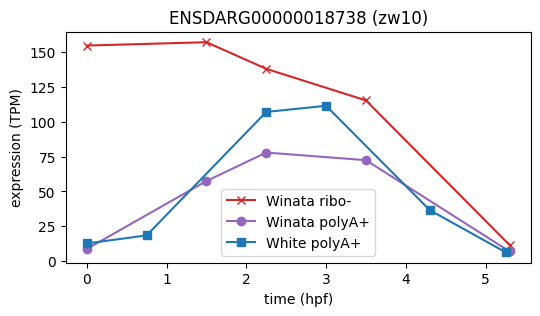

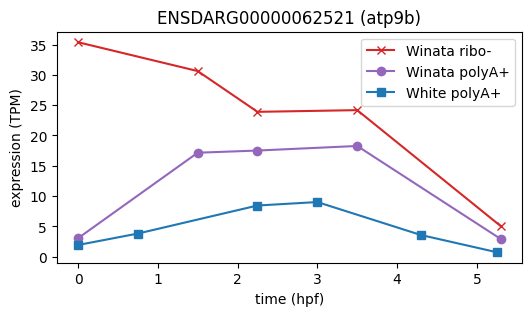

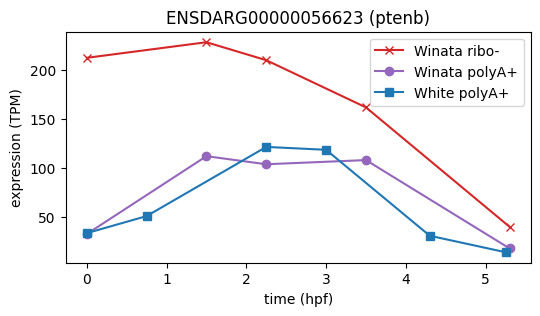

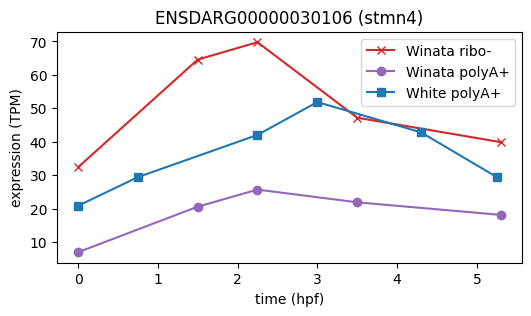

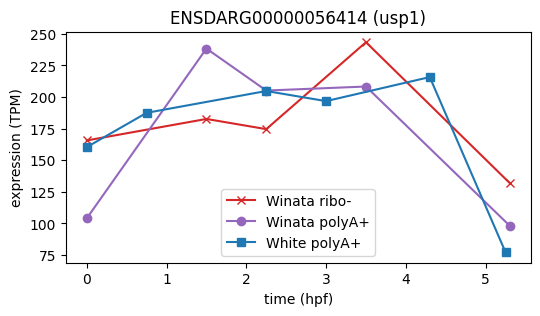

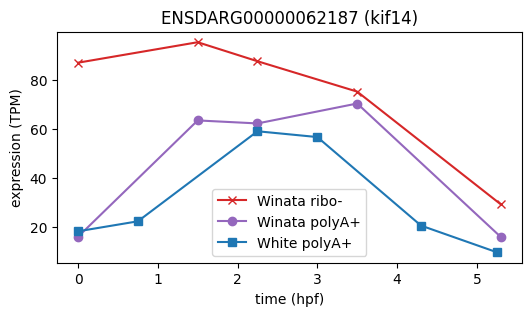

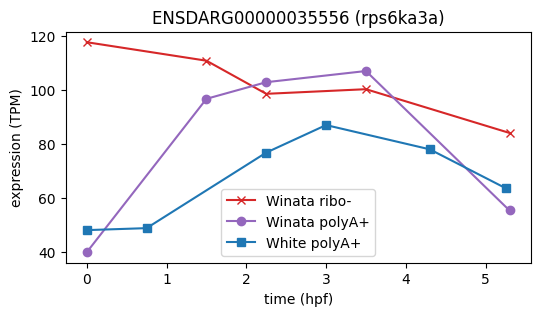

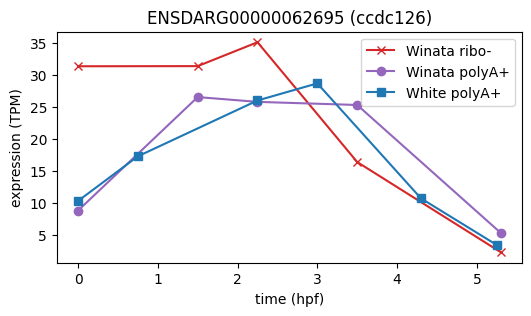

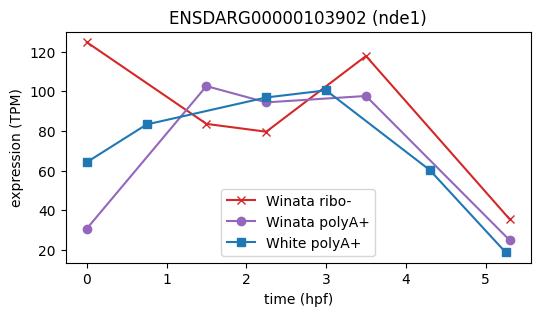

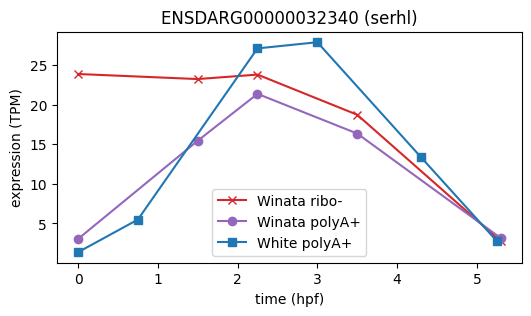

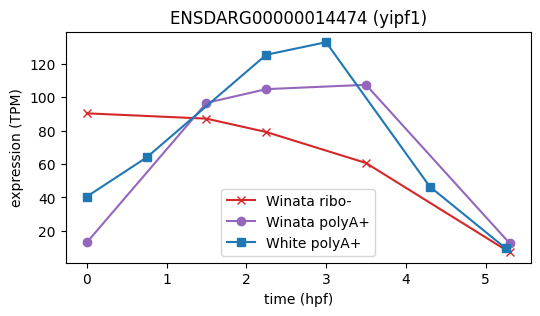

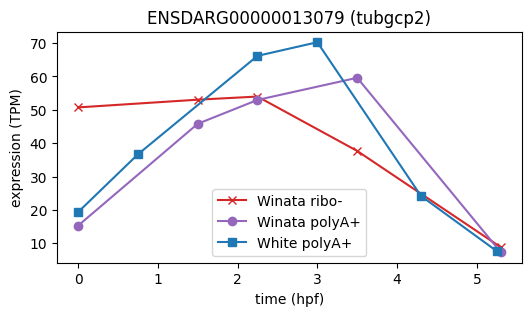

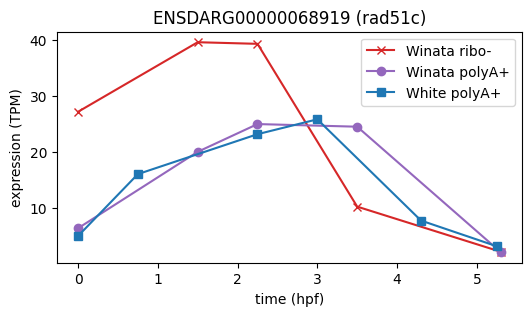

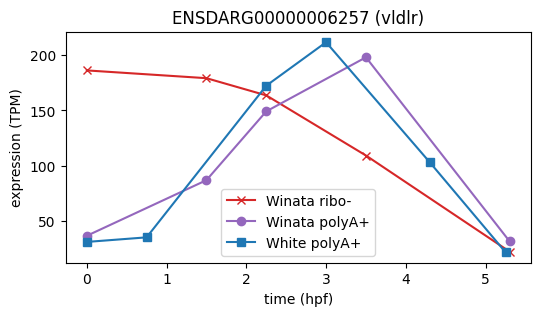

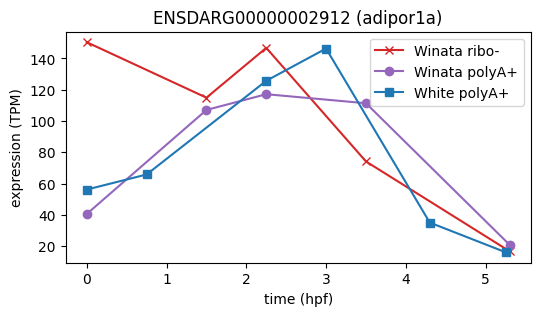

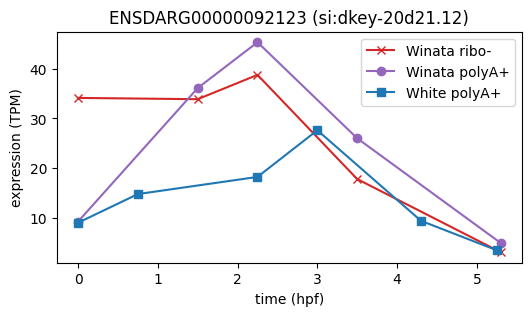

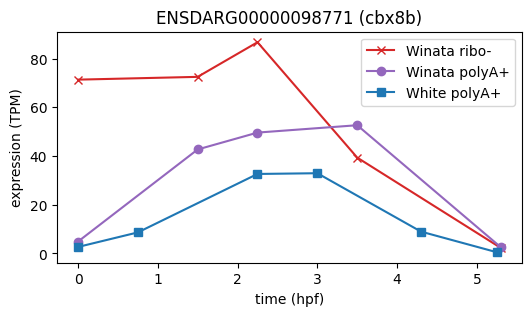

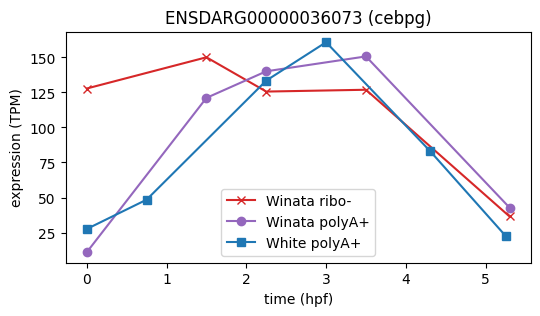

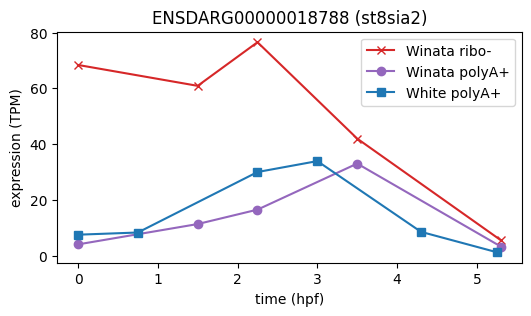

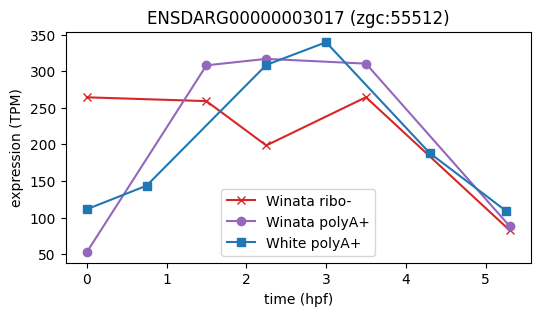

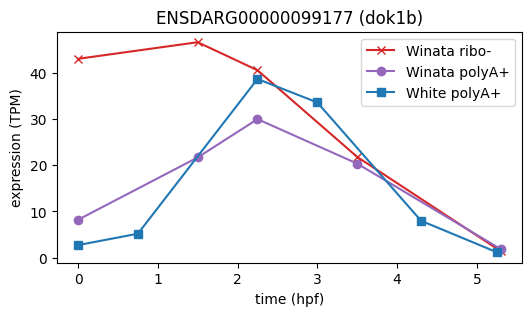

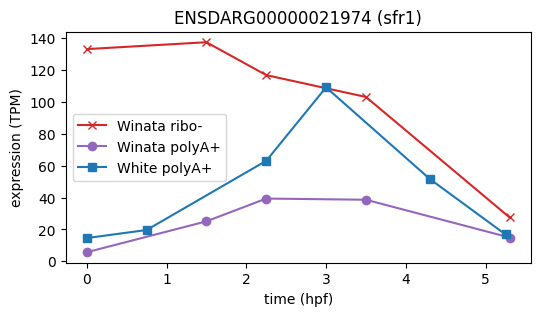

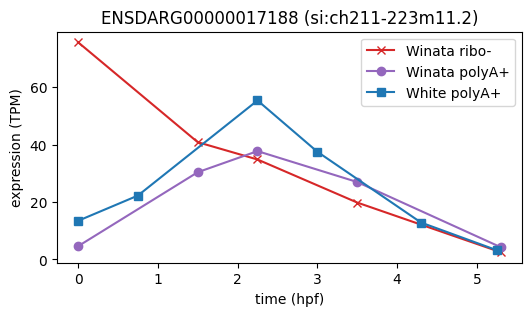

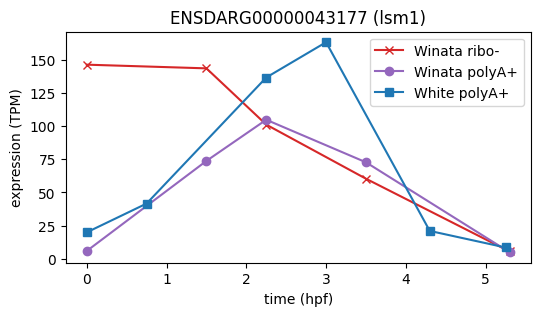

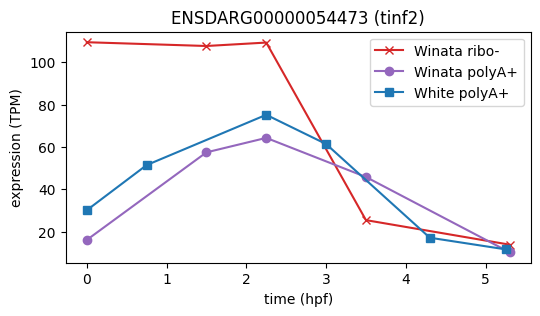

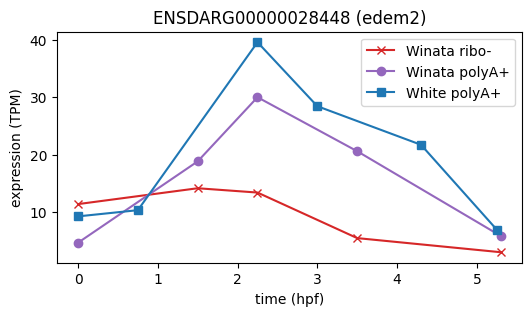

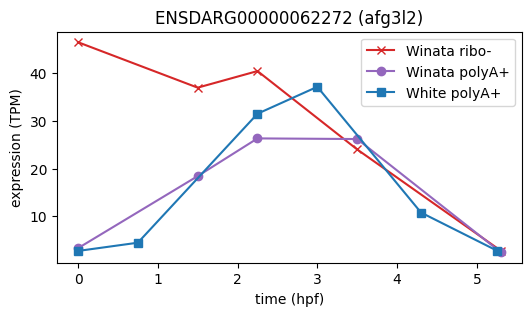

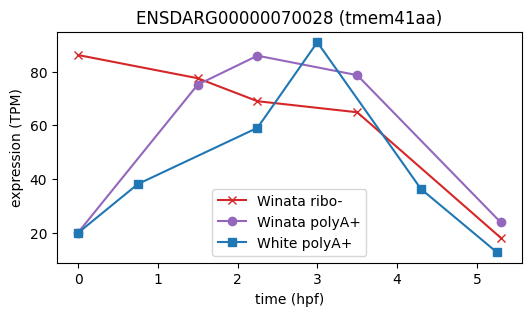

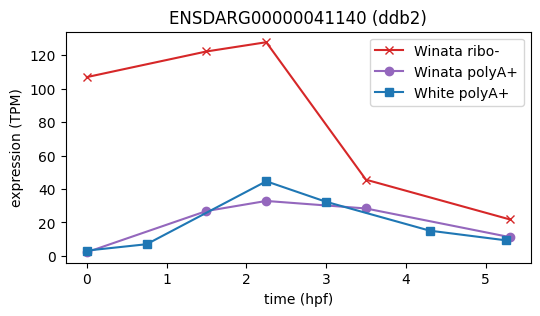

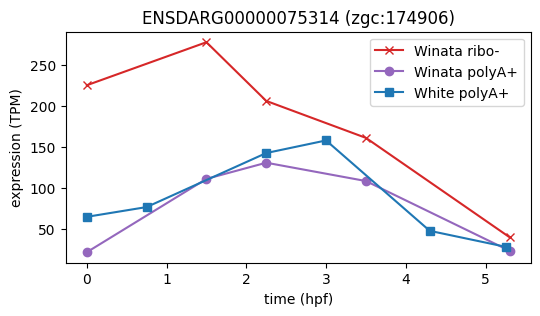

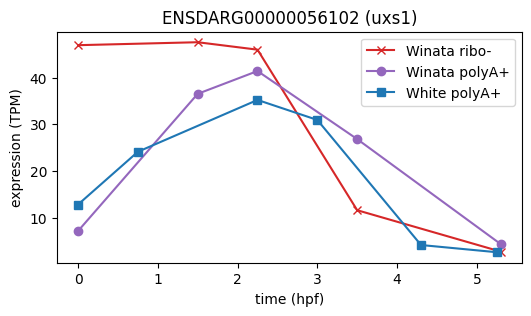

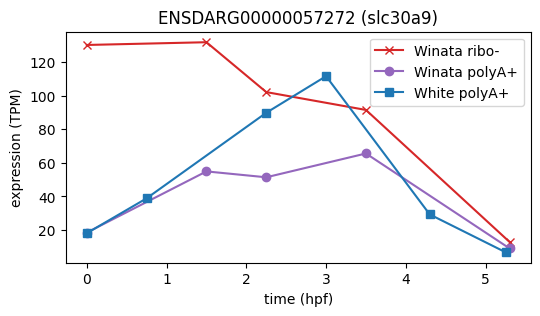

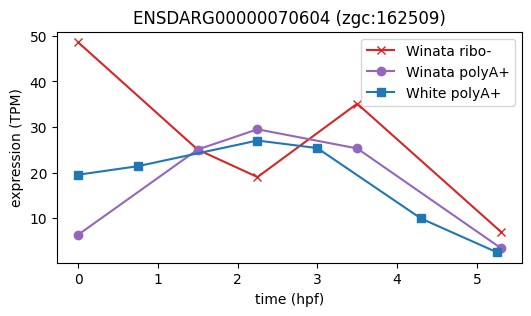

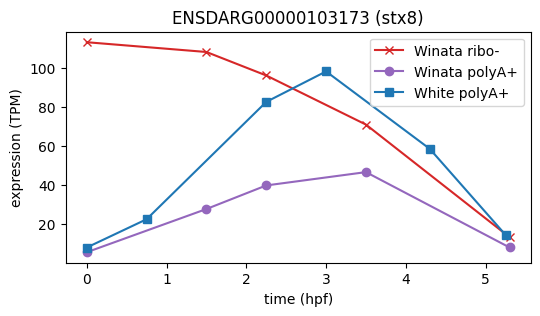

In [ ]:
import matplotlib.pyplot as plt
data_white = xr.load_dataset("data/white_dataset_mean.nc").sel(time=slice(0, 5.25))

for gid in inc_winata_genes.GeneID.values:
    gene = inc_winata_genes.loc[inc_winata_genes["GeneID"] == gid]
    gname = gene.GeneName.item()
    gene_white = data_white.sel(ensembl_gene_id = gid).y

    time = [0, 1.5, 2.25, 3.5, 5.3]
    data_winata_r = [gene["1Cell"], gene["16Cells"],gene["128c"],gene["3.5hpf"],gene["5.3hpf"]]
    data_winata_o = [gene["1Cell.1"], gene["16Cells.1"],gene["128c.1"],gene["3.5hpf.1"],gene["5.3hpf.1"]]

    fig, ax = plt.subplots(figsize=(6,3))
    ax.plot(time, data_winata_r, "x-", label="Winata ribo-", c="tab:red")
    ax.plot(time, data_winata_o, "o-", label="Winata polyA+", c="tab:purple")
    ax.plot(data_white.time, gene_white, "s-", label="White polyA+",  c="tab:blue")
    ax.set(title=f"{gid} ({gname})", xlabel="time (hpf)", ylabel="expression (TPM)")
    ax.legend()
    plt.show()

## Compare oligo(dT) capture vs. ribosomal depletion

In [ ]:
## Data prep
''' ---- NON CPA genes ---- '''

ds = xr.load_dataset("data/white_dataset_mean.nc").sel(time=slice(0, 5.25))

winata_mat_nonCPA = pd.read_excel("data/Winata/TableS2_winata_expression_cluster.xlsx", sheet_name="ribozero.maternal non-CPA")
winata_mat_nonCPA = winata_mat_nonCPA[winata_mat_nonCPA["#geneid"].isin(ds.ensembl_gene_id.values)]
data_winata_non = winata_mat_nonCPA[["#geneid","gene name","1Cell","16Cells","128c","3.5hpf","5.3hpf"]].rename(columns={"#geneid":"GeneID", "gene name":"GeneName", "1Cell":0, "16Cells":1.5, "128c":2.25, "3.5hpf":3.5, "5.3hpf":5.3})

winata_mat_oligo =pd.read_excel("data/Winata/TableS2_winata_expression_cluster.xlsx", sheet_name="oligodT.maternal")
winata_mat_oligo = winata_mat_oligo[winata_mat_oligo["geneid"].isin(data_winata_non.GeneID.values)]
data_winata_oligo = winata_mat_oligo[["geneid","gene name","1Cell","16Cells","128c","3.5hpf","5.3hpf"]].rename(columns={"geneid":"GeneID", "gene name":"GeneName", "1Cell":0, "16Cells":1.5, "128c":2.25, "3.5hpf":3.5, "5.3hpf":5.3})


df_time = data_winata_non.drop(columns=["GeneID", "GeneName"])
ds_winata_nonCPA = xr.DataArray(df_time.values, dims=["ensembl_gene_id", "time"],
    coords={
        "ensembl_gene_id": data_winata_non["GeneID"].values,
        "gene_name": ("ensembl_gene_id", data_winata_non["GeneName"].values),
        "time": df_time.columns.astype(float)
    })
ds_winata_nonCPA.to_netcdf("data/ds_winata_nonCPA_ribo.nc")

df_time = data_winata_oligo.drop(columns=["GeneID", "GeneName"])
ds_winata_oligo = xr.DataArray(df_time.values, dims=["ensembl_gene_id", "time"],
    coords={
        "ensembl_gene_id": data_winata_oligo["GeneID"].values,
        "gene_name": ("ensembl_gene_id", data_winata_oligo["GeneName"].values),
        "time": df_time.columns.astype(float)
    })
ds_winata_oligo.to_netcdf("data/ds_winata_nonCPA_polyA.nc")

ds_white_nonCPA = ds.sel(ensembl_gene_id = ds.ensembl_gene_id.isin(ds_winata_oligo.ensembl_gene_id))
ds_winata_nonCPA = ds_winata_nonCPA.sel(ensembl_gene_id = ds_winata_nonCPA.ensembl_gene_id.isin(ds_winata_oligo.ensembl_gene_id))

''' ---- CPA genes ---- '''

ds = xr.load_dataset("data/white_dataset_mean.nc").sel(time=slice(0, 5.25))
winata_mat_CPA = pd.read_excel("data/Winata/TableS2_winata_expression_cluster.xlsx", sheet_name="ribozero.maternal CPA", header=1)

data_winata_r = winata_mat_CPA[["#geneid","gene name","1Cell","16Cells","128c","3.5hpf","5.3hpf"]].rename(columns={"#geneid":"GeneID", "gene name":"GeneName","1Cell":0, "16Cells":1.5, "128c":2.25, "3.5hpf":3.5, "5.3hpf":5.3})
data_winata_o = winata_mat_CPA[["#geneid.1","gene name.1","1Cell.1","16Cells.1","128c.1","3.5hpf.1","5.3hpf.1"]].rename(columns={"#geneid.1":"GeneID", "gene name.1":"GeneName","1Cell.1":0, "16Cells.1":1.5, "128c.1":2.25, "3.5hpf.1":3.5, "5.3hpf.1":5.3})

df_time = data_winata_r.drop(columns=["GeneID", "GeneName"])
ds_winata_r = xr.DataArray(df_time.values, dims=["ensembl_gene_id", "time"],
    coords={
        "ensembl_gene_id": data_winata_r["GeneID"].values,
        "gene_name": ("ensembl_gene_id", data_winata_r["GeneName"].values),
        "time": df_time.columns.astype(float)
    })
ds_winata_r.to_netcdf("data/ds_winata_CPA_ribo.nc")

df_time = data_winata_o.drop(columns=["GeneID", "GeneName"])
ds_winata_o = xr.DataArray(df_time.values, dims=["ensembl_gene_id", "time"],
    coords={
        "ensembl_gene_id": data_winata_o["GeneID"].values,
        "gene_name": ("ensembl_gene_id", data_winata_o["GeneName"].values),
        "time": df_time.columns.astype(float)
    })
ds_winata_o.to_netcdf("data/ds_winata_CPA_polyA.nc")

ds_white_CPA = ds.sel(ensembl_gene_id = ds.ensembl_gene_id.isin(ds_winata_o.ensembl_gene_id))
ds_winata_r = ds_winata_r.sel(ensembl_gene_id = ds_winata_r.ensembl_gene_id.isin(ds_white_CPA.ensembl_gene_id))
ds_winata_o = ds_winata_o.sel(ensembl_gene_id = ds_winata_o.ensembl_gene_id.isin(ds_white_CPA.ensembl_gene_id))


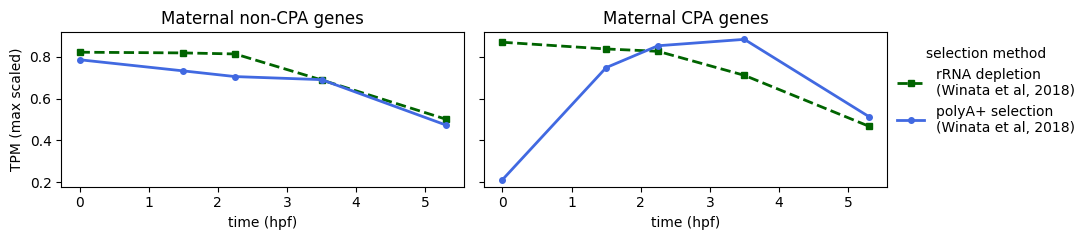

In [ ]:
''' --- Normalisation --- '''
## NON CPA genes
ds_winata_nonCPA = ds_winata_nonCPA/ ds_winata_nonCPA.max("time") 
ds_winata_oligo = ds_winata_oligo / ds_winata_oligo.max("time")
ds_white_nonCPA = ds_white_nonCPA / ds_white_nonCPA.max("time")
## CPA genes
ds_winata_r = ds_winata_r / ds_winata_r.max("time") 
ds_winata_o = ds_winata_o / ds_winata_o.max("time")
ds_white_CPA = ds_white_CPA / ds_white_CPA.max("time")

'''---- PLOT Figure '''
import matplotlib.pyplot as plt
fig, (ax, ax2) = plt.subplots(1,2, figsize=(11, 2.5), sharey=True)

#ax2.plot(ds_white_CPA.time, ds_white_CPA.y.mean(dim="ensembl_gene_id"), c="tab:red", lw=2, marker="o", ms=5,  label="polyA+ selection \n(White et al, 2017)")
ax2.plot(ds_winata_r.time, ds_winata_r.mean("ensembl_gene_id"), lw=2, c="darkgreen", marker="s", ms=5, ls="dashed", label="rRNA depletion \n(Winata et al, 2018)")
ax2.plot(ds_winata_o.time, ds_winata_o.mean("ensembl_gene_id"), lw=2, c="royalblue", marker="o", ms=4, label="polyA+ selection \n(Winata et al, 2018)")

#ax.plot(ds_white_nonCPA.time, ds_white_nonCPA.y.mean(dim="ensembl_gene_id"), c="tab:red", lw=2, marker="o", ms=5,  label="polyA+ selection (White et al, 2017)")
ax.plot(ds_winata_nonCPA.time, ds_winata_nonCPA.mean("ensembl_gene_id"), lw=2, c="darkgreen", marker="s", ms=5, ls="dashed", label="rRNA depletion (Winata et al, 2018)")
ax.plot(ds_winata_oligo.time, ds_winata_oligo.mean("ensembl_gene_id"), lw=2, c="royalblue", marker="o", ms=4, label="polyA+ selection (Winata et al, 2018)")

ax.set(xlabel='time (hpf)',ylabel="TPM (max scaled)",title="Maternal non-CPA genes")
ax2.set(xlabel='time (hpf)',  title="Maternal CPA genes")
ax2.legend(loc=(1.01, 0.3), frameon=False, title="selection method")

#plt.suptitle("Comparison of RNA selection methods for RNA-seq library preparation")
plt.tight_layout()
plt.savefig("figures/expression_genes_o_vs_r.png")

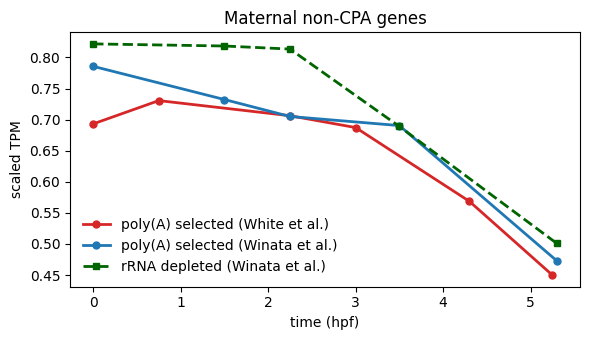

In [13]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

fig, ax2 = plt.subplots(figsize=(6, 3.5), sharey=True)
ax2.plot(ds_white_nonCPA.time, ds_white_nonCPA.y.mean(dim="ensembl_gene_id"), c="tab:red", lw=2, marker="o", ms=5,  label="poly(A) selected (White et al.)")
ax2.plot(ds_winata_oligo.time, ds_winata_oligo.mean(dim="ensembl_gene_id"), c="tab:blue", lw=2, marker="o", ms=5,  label="poly(A) selected (Winata et al.)")
ax2.plot(ds_winata_nonCPA.time, ds_winata_nonCPA.mean("ensembl_gene_id"), lw=2, c="darkgreen", marker="s", ms=5, ls="--", label="rRNA depleted (Winata et al.)")
ax2.set(xlabel='time (hpf)', ylabel="scaled TPM", title="Maternal non-CPA genes")
ax2.legend(loc="best", frameon=False)
plt.tight_layout()
plt.savefig("figures/expression_nonCPA_genes_o_vs_r.png")

181


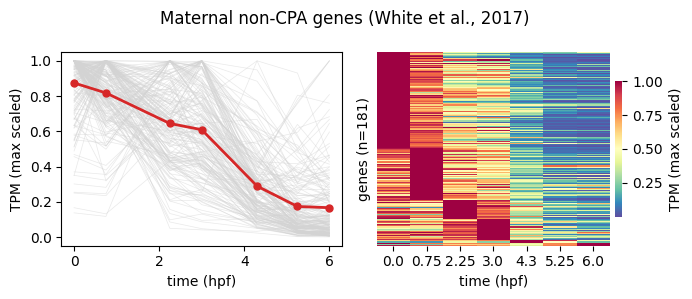

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

#genes = pd.read_csv("inc_winata_genes.csv")
genes = pd.read_csv("winata_nonCPA_genes.csv")
#anaes_inc = ds_increasing.sel(ensembl_gene_id=ds_increasing.ensembl_gene_id.isin(inc_anaes_genes.GeneID)) 
inc = data.sel(ensembl_gene_id=data.ensembl_gene_id.isin(genes.GeneID.values)) 

mask0 = (inc.y.sel(time = 0) > 0).values
ds1 = inc.isel(ensembl_gene_id=mask0)

ds = ds1.sel(ensembl_gene_id=ds1.ensembl_gene_id)  #[0:500]
#ds = np.log1p(ds)
#ds = (ds - ds.mean("time")) / ds.std("time") # z-score
ds = ds/ ds.max("time") # max scaled
#ds = (ds - ds.mean("time")) / abs(ds - ds.mean("time")).max("time") 

# Find time index of max expression for each gene
argmax_time_idx = ds.y.argmax(dim="time").values
# Get sorting indices (earliest peak first)
sort_idx = np.argsort(argmax_time_idx)
# Reorder dataset by peak time
ds = ds.isel(ensembl_gene_id=sort_idx)


print(len(ds.ensembl_gene_id))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7, 3), width_ratios=(0.5, 0.5))
#random_genes = np.random.choice(ds.ensembl_gene_id, 300, replace=False)
for i in ds.ensembl_gene_id:
    ax1.plot(ds.time, ds.y.sel(ensembl_gene_id=i), c="lightgrey", alpha=0.5, lw=0.5)
ax1.plot(ds.time, ds.y.mean(dim="ensembl_gene_id"), c="tab:red", lw=2, label="mean", marker="o", ms=5)
ax1.set(xlabel='time (hpf)', ylabel="TPM (max scaled)")

hm = sns.heatmap(ds.y.T, 
            xticklabels=ds['time'].values,
            yticklabels=ds['ensembl_gene_id'].values,
            ax = ax2,
            cmap='Spectral_r', square=False,
            cbar_kws={'label': 'TPM (max scaled)','shrink': 0.7, 'pad': 0.02 })
ax2.set(xlabel='time (hpf)',  ylabel=f"genes (n={len(ds.ensembl_gene_id)})"     )
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
#ax.set(title=f"Degradation 2 and preMBT 1 genes \n(Anaes et al., 2011)", 
       
ax2.set_yticks([])
plt.suptitle("Maternal non-CPA genes (White et al., 2017)")
#plt.suptitle("Maternal CPA genes (White et al., 2017)")
#.savefig("figures/Heatmap_inc_genes.png")
plt.tight_layout()
#plt.savefig("figures/expression_inc_genes.png")
plt.savefig("figures/expression_nonCPA_genes.png")
plt.show()

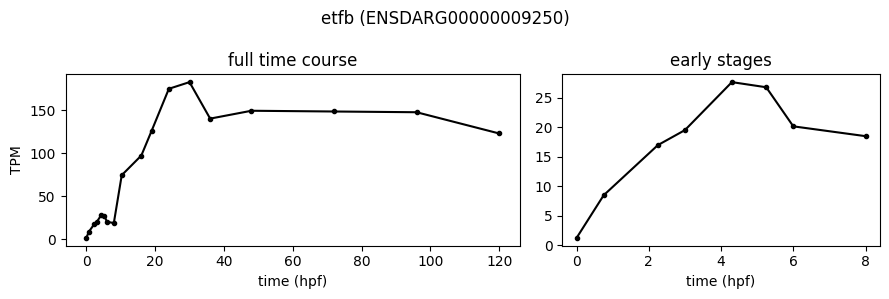

In [ ]:
import matplotlib.pyplot as plt

gene_id = "ENSDARG00000040266" # sox19b
gene_id = "ENSDARG00000003250" 
gene_id = "ENSDARG00000009250" 

ds = pd.read_csv("data/Subtelny/tail_lengths.csv")
name = ds.loc[ds["GeneID"] == gene_id, "GeneName"].item()

data = xr.load_dataset("data/white_dataset_mean.nc")
obs = data.sel(ensembl_gene_id=gene_id)
fig, ax = plt.subplots(1,2, figsize=(9,3), width_ratios=[1,0.7], sharey=False)
ax[0].plot(obs.time, obs.y, c="k", marker=".",)
ax[1].plot(obs.time.sel(time=slice(0, 8)), obs.y.sel(time=slice(0, 8)), c="k", marker=".",)

ax[0].set(title="full time course", xlabel="time (hpf)", ylabel="TPM")
ax[1].set(title="early stages",xlabel="time (hpf)")
plt.suptitle(f"{name} ({gene_id})",)
plt.tight_layout()
plt.savefig(f"figures/expression_{name}_{gene_id}.png")

0.00588957055214724
cluster
1.0    117
3.0      9
0.0      8
2.0      6
4.0      4
Name: count, dtype: int64


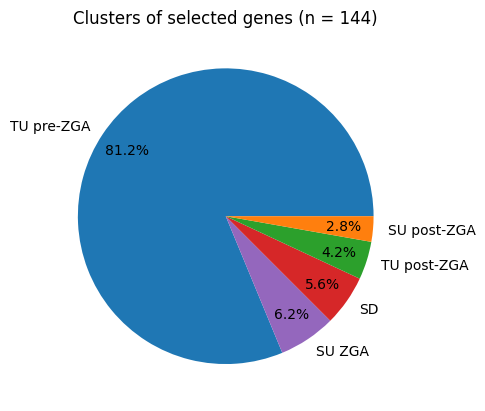

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

ds = pd.read_csv("C:/Users/mgrho/baseline_gene_expression/data/dataset_structure_white_cluster_h.csv")
ds = ds[ds["cluster"] >= 0.0]

#ds = ds[ds["ensembl_gene_id"].isin(ds1.ensembl_gene_id.values)]
#ds = ds[ds["ensembl_gene_id"].isin(ds_increasing.ensembl_gene_id.values)]
#ds = ds[ds["ensembl_gene_id"].isin(inc_anaes_genes.GeneID.values)]
ds = ds[ds["ensembl_gene_id"].isin(inc_winata_genes.GeneID.values)]

print(len(ds) / 24450)
print(ds.cluster.value_counts())

color_dict = {'SD': "tab:red",
              'TU pre-ZGA': "tab:blue",
              'TU post-ZGA': "tab:green", 
              'SU ZGA': "tab:purple",
              'SU post-ZGA': "tab:orange"}

counts = ds.cluster_name.value_counts()
labels = counts.index
colors = [color_dict[label] for label in labels] 

plt.pie(counts, labels=labels,
        colors=colors,
        autopct='%1.1f%%', pctdistance=0.8)

plt.title(f"Clusters of selected genes (n = {len(ds)})")
#plt.tight_layout()
plt.savefig("figures/clusters_inc_CPA_genes.png")
plt.show()

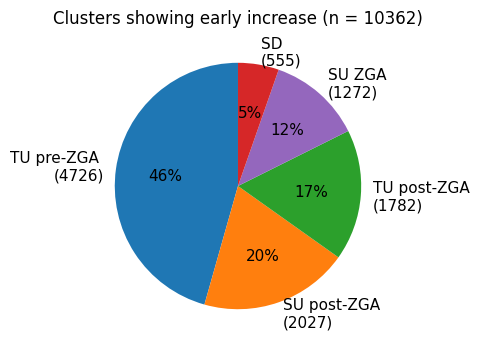

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

color_dict = {'SD': "tab:red",
              'TU pre-ZGA': "tab:blue",
              'TU post-ZGA': "tab:green", 
              'SU ZGA': "tab:purple",
              'SU post-ZGA': "tab:orange"}

ds = pd.read_csv("C:/Users/mgrho/baseline_gene_expression/data/dataset_structure_white_cluster_h.csv")
ds = ds[ds["cluster"] >= 0.0]

ds = ds[ds["ensembl_gene_id"].isin(ds_increasing.ensembl_gene_id.values)]
ds.cluster_name.value_counts()

counts = ds.cluster_name.value_counts()
labels = counts.index
colors = [color_dict[label] for label in labels] 
labels = [f"{idx} \n({val})" for idx, val in zip(counts.index, counts.values)]

fig = plt.figure(figsize=(5,4))
plt.pie(counts, labels=labels, colors=colors,startangle=90,
        autopct='%1.0f%%', pctdistance=0.6, textprops={'fontsize': 11})
plt.title(f"Clusters showing early increase (n = {len(ds)})", fontsize=12)
plt.savefig("figures/clusters_inc_genes_full.png")

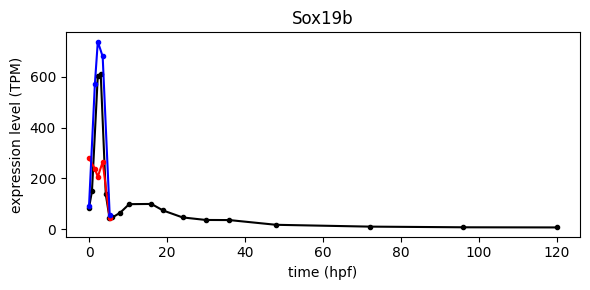

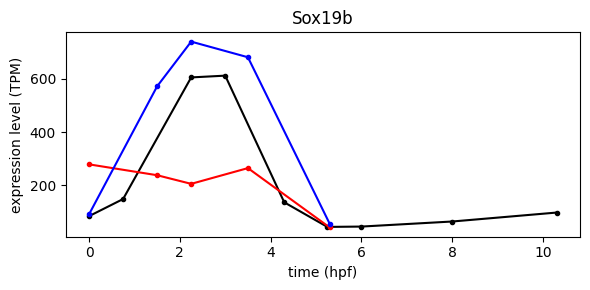

In [148]:
import matplotlib.pyplot as plt
gene="ENSDARG00000040266"
ds = xr.load_dataset("data/white_dataset_mean.nc")
ds_o = xr.load_dataarray("data/ds_winata_CPA_polyA.nc")
ds_r = xr.load_dataarray("data/ds_winata_CPA_ribo.nc")
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(ds.time, ds.sel(ensembl_gene_id=gene).y, "k.-")
ax.plot(ds_r.time, ds_r.sel(ensembl_gene_id=gene), "r.-")
ax.plot(ds_o.time, ds_o.sel(ensembl_gene_id=gene), "b.-")
ax.set(title = "Sox19b", xlabel="time (hpf)", ylabel="expression level (TPM)")
plt.tight_layout()
## shorter time
ds = xr.load_dataset("data/white_dataset_mean.nc").sel(time=slice(0, 12))
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(ds.time, ds.sel(ensembl_gene_id=gene).y, "k.-")
ax.plot(ds_r.time, ds_r.sel(ensembl_gene_id=gene), "r.-")
ax.plot(ds_o.time, ds_o.sel(ensembl_gene_id=gene), "b.-")
ax.set(title = "Sox19b", xlabel="time (hpf)", ylabel="expression level (TPM)")
plt.tight_layout()